# E-Commerce Basket Analysis: An Exploratory Data Analysis

### Analytical Question
How do customer purchases vary over time, and what patterns can be observed in product purchases and basket quantities?

## Objective
The objective of this project is to perform Exploratory Data Analysis on e-commerce transaction data and identify meaningful patterns in customer purchases, product activity, basket quantities, and purchasing trends over time.



## Dataset Source and Description
This dataset contains e-commerce basket transaction records. Each record represents a customer's purchase activity for a product on a particular date.
The dataset contains 15,000 records and 4 columns: customer ID, product ID, basket date, and basket count.
The main variables used for analysis are customer activity, product purchases, basket quantity, and purchase date.



## Import Required Libraries
The following Python libraries are used for data analysis and visualisation. Pandas is used for tabular data exploration, NumPy is used for numerical array operations, Matplotlib and Seaborn are used for visualisation, and Plotly can be used for interactive visualisation.


In [42]:
%pip install seaborn


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Dataset Loading
The e-commerce basket dataset is loaded into a Pandas DataFrame for further exploration and analysis.



In [44]:
data = pd.read_csv("E-commerce.csv")


In [45]:
data.head()


,customer_id,product_id,basket_date,basket_count
0,42366585,41475073,2019-06-19,2
1,35956841,43279538,2019-06-19,2
2,26139578,31715598,2019-06-19,3
3,3262253,47880260,2019-06-19,2
4,20056678,44747002,2019-06-19,2


In [46]:
data.shape



(15000, 4)

In [47]:
data.columns


Index(['customer_id', 'product_id', 'basket_date', 'basket_count'], dtype='object')

## Data Understanding
The dataset contains customer-level and product-level purchase information along with the date of purchase and the number of items in each basket. Understanding these variables helps identify customer activity, product purchasing patterns, and changes in basket quantities over time.


In [48]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   customer_id   15000 non-null  int64 
 1   product_id    15000 non-null  int64 
 2   basket_date   15000 non-null  object
 3   basket_count  15000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 468.9+ KB


In [49]:
data.describe()



,customer_id,product_id,basket_count
count,1.500000e+04,1.500000e+04,15000.000000
mean,1.808567e+07,3.269771e+07,2.153733
std,1.233000e+07,1.629455e+07,0.517929
min,4.784000e+03,4.939000e+04,2.000000
25%,8.659327e+06,3.137412e+07,2.000000
50%,1.520775e+07,3.694759e+07,2.000000
75%,2.663904e+07,4.502408e+07,2.000000
max,4.460824e+07,5.579097e+07,10.000000


## Data-Type Classification
•⁠  ⁠*customer_id* → Categorical/Identifier: uniquely identifies a customer.
•⁠  ⁠*product_id* → Categorical/Identifier: identifies the product involved in the transaction.
•⁠  ⁠*basket_date* → Time-series: represents the date on which the purchase activity occurred.
•⁠  ⁠*basket_count* → Numerical: represents the quantity of items in the customer's basket.


### Important Columns for the Analytical Question
•⁠  ⁠*customer_id* is important for understanding customer purchasing activity.
•⁠  ⁠*product_id* is important for analysing product-level purchasing patterns.
•⁠  ⁠*basket_date* is important for studying changes in purchasing activity over time.
•⁠  ⁠*basket_count* is important for analysing the quantity of items purchased in each transaction.


### Expected Value of Performing EDA
Exploratory Data Analysis helps identify purchasing patterns, frequently purchased products, basket quantity distributions, and changes in transaction activity over time. It also helps detect data-quality issues before further analysis.



## Data Quality Exploration
Data quality is checked by examining missing values, duplicate records, and unusual values. These checks help ensure that the dataset is suitable for further analysis and visualisation.



In [50]:
data.isnull().sum()


customer_id     0
product_id      0
basket_date     0
basket_count    0
dtype: int64

In [51]:
data.duplicated().sum()


np.int64(0)

## NumPy Array Demonstrations
NumPy is used to demonstrate array creation, array properties, indexing, slicing, reshaping, vectorization, broadcasting, aggregation, Boolean indexing, fancy indexing, and reproducible random-number generation.


In [52]:
arr = np.array(data["basket_count"])
print(arr)

[2 2 3 ... 2 2 2]


In [53]:
zeros_arr = np.zeros(5)
print(zeros_arr)

[0. 0. 0. 0. 0.]


In [54]:
ones_arr = np.ones(5)
print(ones_arr)

[1. 1. 1. 1. 1.]


In [55]:
arange_arr = np.arange(1, 11)
print(arange_arr)

[ 1  2  3  4  5  6  7  8  9 10]


In [56]:
arr.shape

(15000,)

In [57]:
print("ndim:",arr.ndim)
print("dtype:",arr.dtype)
print("size:",arr.size)
print("itemsize:",arr.itemsize)

ndim: 1
dtype: int64
size: 15000
itemsize: 8


In [58]:
print(arr[0])

2


In [59]:
print(arr[0:5])

[2 2 3 2 2]


In [60]:
arr_2d = arr.reshape(150, 100)
print(arr_2d)

[[2 2 3 ... 2 2 2]
 [3 2 2 ... 3 2 2]
 [2 2 2 ... 2 2 2]
 ...
 [2 3 2 ... 2 2 3]
 [2 2 2 ... 2 3 3]
 [2 2 2 ... 2 2 2]]


In [61]:
arr_2d.shape

(150, 100)

In [62]:
print(arr_2d[0, 0])

2


In [63]:
print(arr_2d[0:3, 0:3])

[[2 2 3]
 [3 2 2]
 [2 2 2]]


In [64]:
arr_3d=arr.reshape(15,10,100)
print(arr_3d)
arr_3d.shape

[[[2 2 3 ... 2 2 2]
  [3 2 2 ... 3 2 2]
  [2 2 2 ... 2 2 2]
  ...
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]]

 [[2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 4]
  [2 2 2 ... 2 2 2]
  ...
  [3 2 3 ... 3 2 2]
  [2 2 3 ... 2 2 2]
  [2 2 2 ... 2 2 2]]

 [[2 2 2 ... 2 2 3]
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 3 2 2]
  ...
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]]

 ...

 [[2 3 3 ... 2 2 2]
  [2 2 2 ... 2 2 2]
  [2 3 2 ... 2 3 2]
  ...
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]]

 [[2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 3 2 2]
  ...
  [2 2 2 ... 2 2 2]
  [2 3 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]]

 [[2 2 2 ... 2 3 2]
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]
  ...
  [2 3 2 ... 2 2 3]
  [2 2 2 ... 2 3 3]
  [2 2 2 ... 2 2 2]]]


(15, 10, 100)

In [65]:
print(arr_3d[0, 2, 5])

2


In [66]:
reshaped_2D_array=arr_2d.reshape(300, 50)
print("Reshaped:", reshaped_2D_array)

Reshaped: [[2 2 3 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 [3 2 2 ... 2 2 2]
 ...
 [2 2 2 ... 2 3 3]
 [2 2 2 ... 2 3 3]
 [4 3 2 ... 2 2 2]]


In [67]:
flattened_array = arr_2d.flatten()
print("Flattened:", flattened_array)

Flattened: [2 2 3 ... 2 2 2]


In [68]:
raveled_array = arr_2d.ravel()
print("Raveled:", raveled_array)

Raveled: [2 2 3 ... 2 2 2]


In [69]:
transposed_array = arr_2d.transpose()
print("Transposed:", transposed_array)

Transposed: [[2 3 2 ... 2 2 2]
 [2 2 2 ... 3 2 2]
 [3 2 2 ... 2 2 2]
 ...
 [2 3 2 ... 2 2 2]
 [2 2 2 ... 2 3 2]
 [2 2 2 ... 3 3 2]]


In [70]:
doubled_array=arr*2
print("Doubled:",doubled_array)

Doubled: [4 4 6 ... 4 4 4]


In [71]:
broadcasted_array=arr+10
print("Broadcasted:",broadcasted_array)

Broadcasted: [12 12 13 ... 12 12 12]


In [72]:
print(f"Sum:{np.sum(arr):.2f}")
print(f"Mean:{np.mean(arr):.2f}")
print(f"Minimum:{np.min(arr):.2f}")
print(f"Maximum:{np.max(arr):.2f}")
print(f"Standard Deviation:{np.std(arr):.2f}")
print(f"Variance:{np.var(arr):.2f}")

Sum:32306.00
Mean:2.15
Minimum:2.00
Maximum:10.00
Standard Deviation:0.52
Variance:0.27


In [73]:
print("Row-wise sum:",np.sum(arr_2d, axis=1))
print("Column-wise sum:",np.sum(arr_2d, axis=0))

Row-wise sum: [210 212 216 216 211 219 223 222 213 214 218 212 217 215 216 210 210 219
 220 213 215 216 214 211 214 241 221 218 206 218 207 213 215 222 210 229
 218 219 215 214 210 212 212 220 212 211 215 208 215 223 212 219 219 211
 216 207 214 241 218 221 216 217 207 230 207 214 211 212 218 213 215 211
 215 213 215 208 224 217 220 225 209 209 218 201 221 212 222 214 218 216
 217 207 217 217 209 220 218 210 219 212 214 209 217 214 211 216 213 215
 207 209 218 215 214 222 221 219 230 210 221 217 216 210 213 215 223 211
 214 210 207 220 212 210 219 214 214 210 226 218 217 208 217 205 215 208
 205 223 227 221 215 219]
Column-wise sum: [319 325 318 317 316 316 321 319 321 325 320 325 332 319 315 314 317 320
 324 337 324 328 315 327 329 326 319 321 333 315 322 328 332 323 329 319
 326 321 319 310 326 320 317 330 318 323 325 317 317 333 317 331 330 318
 326 330 310 319 325 325 321 316 330 327 335 329 327 330 322 323 324 324
 331 321 320 325 322 325 321 328 323 310 321 323 326 325 322 323 32

In [74]:
high_basket=arr[arr>5]
print("Basket counts greater than 10:",high_basket)

Basket counts greater than 10: [ 6  8  7  7  7  8 10  6  6  6  7  7  6  7  6  6  6  6  9  6  8  6  6  8
  6  6  7  7  6  6  7  7  6  6  6 10  9  6  6  6  7  8  6  6  8  6  7  8
  8  6  6  7  8  8]


In [75]:
selected_values=arr[[0, 5, 10, 15]]
print("Selected values:",selected_values)

Selected values: [2 2 6 2]


In [76]:
np.random.seed(42)
random_array = np.random.randint(1,101,10)
print("Random values:",random_array)

Random values: [52 93 15 72 61 21 83 87 75 75]


## Visualisation and Interpretation
Visualisations are used to understand purchasing behaviour in the e-commerce dataset. The analysis focuses on basket quantities, purchasing activity over time, and product-level purchase patterns.


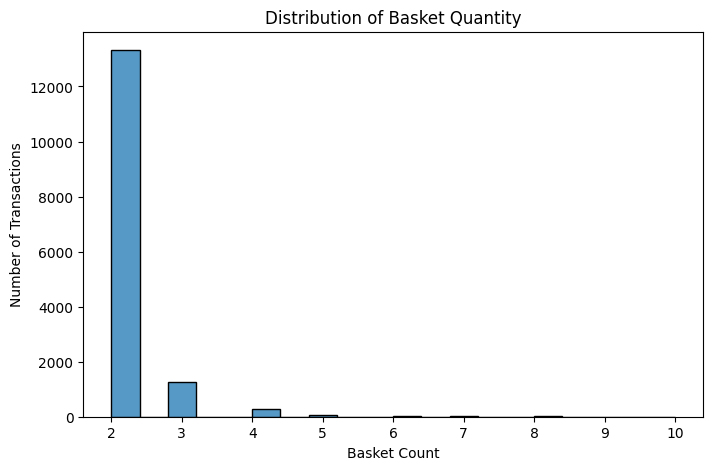

In [77]:
plt.figure(figsize=(8,5))
sns.histplot(data["basket_count"], bins=20)
plt.title("Distribution of Basket Quantity")
plt.xlabel("Basket Count")
plt.ylabel("Number of Transactions")
plt.show()


### Observations
•⁠  ⁠Most transactions have a basket count of 2, making it the most common basket quantity in the dataset.
•⁠  ⁠Basket counts greater than 3 occur much less frequently, showing that larger basket quantities are relatively uncommon.



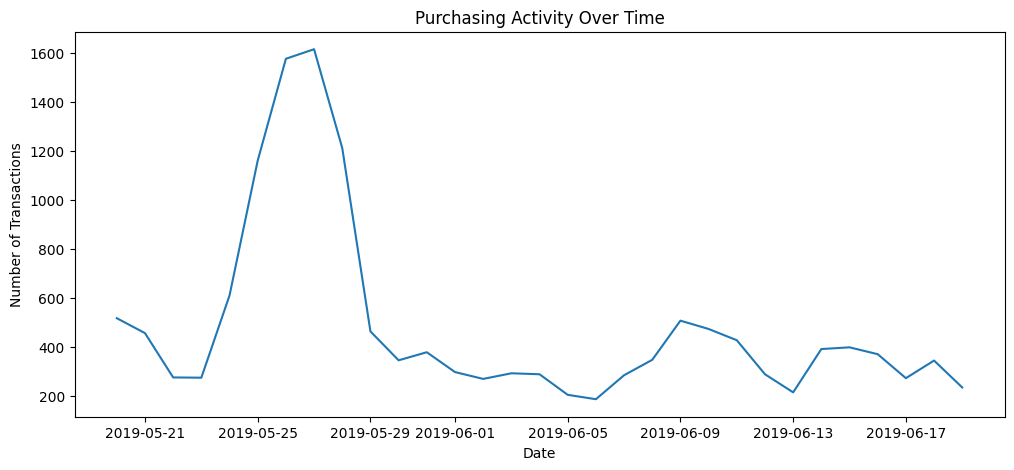

In [78]:
data["basket_date"] = pd.to_datetime(data["basket_date"])
daily_transactions = data.groupby("basket_date").size()
plt.figure(figsize=(12,5))
plt.plot(daily_transactions)
plt.title("Purchasing Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.show()

### Observations
- The number of transactions varies considerably across different dates, showing changes in purchasing activity over time.
- A major increase in transactions can be observed around 25–28 May 2019, where the number of transactions reaches its highest level.

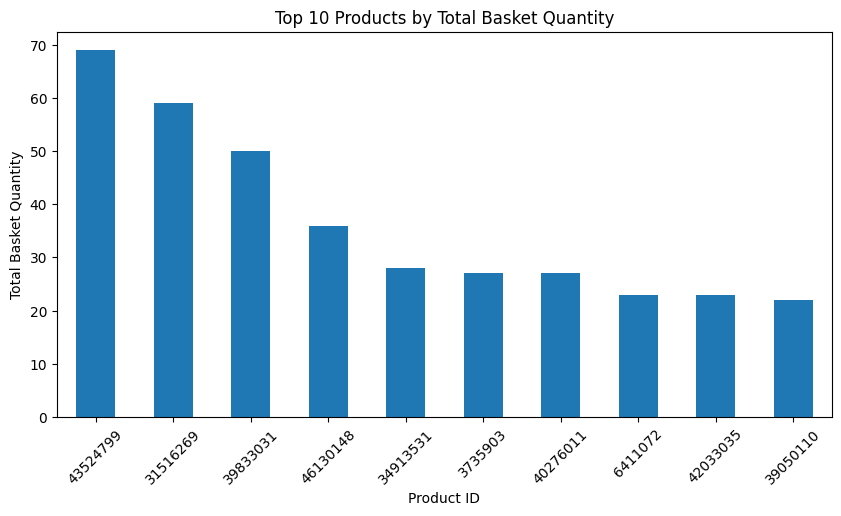

In [79]:
top_products = data.groupby("product_id")["basket_count"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Total Basket Quantity")
plt.xlabel("Product ID")
plt.ylabel("Total Basket Quantity")
plt.xticks(rotation=45)
plt.show()

### Observations
- Product ID **43524799** has the highest total basket quantity among the top 10 products, with approximately 69 items.
- The total basket quantity decreases across the ranked products, with the remaining products showing lower purchasing quantities.

## Key Findings
- Most transactions have a basket count of 2, while larger basket quantities occur less frequently.
- Purchasing activity varies across dates, with a major increase in transactions observed around 25–28 May 2019.
- Product purchasing activity is not evenly distributed, with some products having higher total basket quantities than others.

## Answer to the Analytical Question
The analysis shows that customer purchasing activity varies across different dates and products. Most transactions have a basket count of 2, while larger basket quantities are less common. Purchasing activity also changes over time, with a noticeable increase around 25–28 May 2019. The product analysis shows that some products have higher total basket quantities than others, indicating differences in product purchasing activity.

## Observations vs Assumptions

### Observations
- Most transactions have a basket count of 2, while higher basket quantities occur less frequently.
- Purchasing activity varies across different dates, with a major increase around 25–28 May 2019.
- Some products have higher total basket quantities than others.

### Assumptions
- The observed purchasing patterns are interpreted only from the available transaction data.
- The analysis does not assume that any observed purchasing pattern is caused by a specific external factor.

## Limitations
- The dataset contains transaction records for a specific set of customers and products, so the findings may not represent all e-commerce customers or products.
- The dataset provides limited information about customers and transactions, so factors such as customer demographics, product prices, and reasons for purchasing behaviour cannot be analysed.

## Follow-up Analysis
- Analyse customer purchasing frequency to identify different patterns of customer activity.
- Study product-level purchasing behaviour in greater detail by comparing product popularity and basket quantities over time.

## Conclusion
The exploratory analysis of the e-commerce basket dataset provides insights into customer purchasing activity, product purchases, basket quantities, and purchasing patterns over time. Most transactions have a basket count of 2, while purchasing activity varies across different dates and products. Overall, the analysis demonstrates how Exploratory Data Analysis can be used to identify meaningful patterns in e-commerce transaction data without making unsupported causal assumptions.